# Research Report Topic （Option-1）
Use the image data from following source and create a model to train and test images for following categories of diagnosis:

Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Infiltration, Mass, Nodule, Pneumonia, Pneumothorax, Pleural, No Findings

In [ ]:
!nvidia-smi

In [ ]:
import os
import sys
import random
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import KFold

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True     # Auto-select fastest kernels
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.allow_tf32 = True    # A100 accelerated matmul with TF32

# CUDA MATMUL / TF32 SETTINGS
torch.backends.cuda.matmul.allow_tf32 = True   # HUGE speedup for convs + matmuls

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!cp -r /content/drive/MyDrive/archive.zip /content/

In [ ]:
# unzip
!unzip /content/archive.zip

## According to the assignment requirements, remove the **Hernia** folder.


In [ ]:
!rm -rf '/content/Nih All d/Hernia'

## Hyperparameter tuning.

We tried the hyperparameters below. We mark out the hyperparameters used in the cell below. We use droput=0.2 in densenet-121 backbone for optimal accuracy.

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 128
EPOCHS = 10

# All hyperparameters are tuned.
LR = 5e-5 # 1e-3, 2e-4, 5e-4, 5e-5, 2e-5, 1e-5, 1e-4
WD = 1e-4 # 1e-3, 2e-4, 5e-4, 5e-5, 2e-5, 1e-5, 1e-4
DROPOUT = 0.1 # zero dropout, use regularization (Wd) to prevent overfitting.


## Torch optimization flags

Pytorch optimization flags to ensure that pipeline runs smoothly.

In [ ]:
NUM_WORKERS = 12
DATA_ROOT = "/content/Nih All d"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Mixed precision (good speedup on modern GPUs)
USE_AMP = (DEVICE.type == "cuda")

# For A100 / modern GPUs
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True
try:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
except AttributeError:
    pass  # older PyTorch

# Reproducibility
SEED = 7
random.seed(SEED)

Using device: cuda


## Class Setup

In [ ]:
# 14 classes, "No Findings" is last
CLASS_NAMES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Effusion",
    "Emphysema",
    "Fibrosis",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Pleural",
    "No Findings",   # negative class
]
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

# some datasets use "No Finding" as folder name etc.
FOLDER_ALIASES = {
    "No Findings": ["No Findings", "No Finding", "NoFinding"]
}

### Data augmentation

For training, use horizontal flip and color jittering (brightness, contrast etc.)

For validtation, only resize and normalize is applied.

In [ ]:
#Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.ColorJitter(
        brightness=0.2,   # ±20% brightness
        contrast=0.2,     # ±20% contrast
        saturation=0.1,   # small saturation jitter (safe even if images are near-grayscale)
    ),
    transforms.RandomAffine(
        degrees=5,             # small rotation
        translate=(0.05, 0.05),# up to 5% shift
        scale=(0.95, 1.05),    # small zoom in/out
        fill=0                 # background fill
    ),
    transforms.Normalize(
        mean=[.5, .5, .5],
        std=[0.225, 0.225, 0.225],
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[.5, .5, .5],
        std=[0.225, 0.225, 0.225],
    ),
])


## Build Image → Labels Map

In [ ]:
def build_image_label_map(data_root):
    data_root = Path(data_root)
    image_to_labels = defaultdict(list)

    for cls in CLASS_NAMES:
        # resolve folder names (to handle No Finding vs No Findings)
        folder_candidates = FOLDER_ALIASES.get(cls, [cls])
        folder_path = None
        for cand in folder_candidates:
            p = data_root / cand
            if p.exists():
                folder_path = p
                break

        if folder_path is None:
            print(f"[WARN] Folder for class '{cls}' not found. Tried: {folder_candidates}")
            continue

        for fname in os.listdir(folder_path):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            img_path = str(folder_path / fname)
            image_to_labels[img_path].append(cls)

    print(f"Total unique images found: {len(image_to_labels)}")
    return image_to_labels


## Encode Multi-Label Vector

In [ ]:
def encode_labels(label_list):
    vec = torch.zeros(NUM_CLASSES, dtype=torch.float32)
    normalized = []

    for l in label_list:
        if l in ("No Finding", "No Findings", "NoFinding"):
            normalized.append("No Findings")
        else:
            normalized.append(l)

    if len(normalized) == 1 and normalized[0] == "No Findings":
        vec[CLASS_TO_IDX["No Findings"]] = 1.0
        return vec

    for l in normalized:
        if l == "No Findings":
            continue
        if l in CLASS_TO_IDX:
            vec[CLASS_TO_IDX[l]] = 1.0

    return vec


## Dataset Class

In [ ]:
class NIHMultiLabelDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, labels = self.items[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        target = encode_labels(labels)
        return img, target

## Dataloaders & Model function

Use densenet-121 with pretrained weights (imagenet-1k) as backbone.

In [ ]:
# ============================================================
# DATALOADERS
# ============================================================
def make_dataloaders(data_root, batch_size, num_workers=4,
                     train_ratio=0.8, val_ratio=0.1, test_ratio=0.1): # 90% train(10% val) / 10% test
    image_to_labels = build_image_label_map(data_root)
    items = list(image_to_labels.items())

    random.shuffle(items)
    n = len(items)
    n_train = int(n * train_ratio)
    n_val = int(n * (train_ratio + val_ratio))

    train_items = items[:n_train]
    val_items   = items[n_train:n_val]
    test_items  = items[n_val:]

    print(f"Train: {len(train_items)}, Val: {len(val_items)}, Test: {len(test_items)}")

    train_ds = NIHMultiLabelDataset(train_items, transform=train_transform)
    val_ds   = NIHMultiLabelDataset(val_items,   transform=val_transform)
    test_ds  = NIHMultiLabelDataset(test_items,  transform=val_transform)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True,
        persistent_workers=(num_workers > 0)
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
        persistent_workers=(num_workers > 0)
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
        persistent_workers=(num_workers > 0)
    )

    return train_loader, val_loader, test_loader

# ============================================================
# MODEL
# ============================================================
def build_model(num_classes):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    in_features = model.classifier.in_features
    if DROPOUT == 0.0:
      model.classifier = torch.nn.Linear(in_features, num_classes)
    else:
      model.classifier = nn.Sequential(
          torch.nn.Dropout(DROPOUT),
          torch.nn.Linear(in_features, num_classes)
      ) # logits for each label
    model = model.to(DEVICE)
    return model

## Train / Validation Function Loops (Multi-Label)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, epoch, scaler, threshold=0.5):
    model.train()
    running_loss = 0.0
    total_samples = 0

    # label-wise accuracy
    running_label_correct = 0.0
    running_label_total = 0.0

    running_example_acc = 0.0
    running_example_acc_cnt = 0.0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch}", file=sys.stdout, leave=False)

    for images, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)   # [B, C]

        optimizer.zero_grad(set_to_none=True)

        # forward + loss in mixed precision if enabled
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            outputs = model(images)                     # [B, C] logits
            loss = criterion(outputs, labels)

        if scaler is not None and USE_AMP:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = images.size(0)
        total_samples += batch_size
        running_loss += loss.item() * batch_size

        # ---- Compute predictions (still in full precision here) ----
        probs = torch.sigmoid(outputs)
        preds = (probs > threshold).float()             # [B, C]

        # ---- Label-wise accuracy ----
        correct_label = (preds == labels).float()       # [B, C]
        running_label_correct += correct_label.sum().item()
        running_label_total += correct_label.numel()

        # calculate correct positive labels
        #false_pos = ((preds == 1) & (labels == 0)).float().sum()
        #false_neg = ((preds == 0) & (labels == 1)).float().sum()
        #print(f"False pos: {false_pos}, false neg: {false_neg}")



        pbar.set_postfix({
            "loss": f"{running_loss / total_samples:.4f}",
            "label_acc": f"{100.0 * running_label_correct / running_label_total:.2f}%",
        })

    epoch_loss = running_loss / total_samples
    epoch_label_acc = running_label_correct / running_label_total
    return epoch_loss, epoch_label_acc

def validate_epoch(model, loader, criterion, epoch, threshold=0.5, desc_prefix="Val"):
    model.eval()
    running_loss = 0.0
    total_samples = 0

    running_label_correct = 0.0
    running_label_total = 0.0

    running_example_acc = 0.0
    running_example_acc_cnt = 0.0

    pbar = tqdm(loader, desc=f"{desc_prefix} Epoch {epoch}", file=sys.stdout, leave=False)

    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)

            batch_size = images.size(0)
            total_samples += batch_size
            running_loss += loss.item() * batch_size

            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()

            correct_label = (preds == labels).float()
            running_label_correct += correct_label.sum().item()
            running_label_total += correct_label.numel()

            # calculate correct positive labels
            #false_pos = ((preds == 1) & (labels == 0)).float().sum()
            #false_neg = ((preds == 0) & (labels == 1)).float().sum()
            #print("False pos: {false_pos}, false neg: {false_neg}")

            pbar.set_postfix({
                "loss": f"{running_loss / total_samples:.4f}",
                "label_acc": f"{100.0 * running_label_correct / running_label_total:.2f}%",
            })

    epoch_loss = running_loss / total_samples
    epoch_label_acc = running_label_correct / running_label_total

    return epoch_loss, epoch_label_acc


## Dataloader, model, loss and optimizer setup

We setup dataloader to read data with training/validation data augmentation. We use AdamW as the optimizer (decoupled weights from Adam) and use binary cross entropy per class. This is because we identify that each image is associated with more than one positive label (e.g.,"Atelectasis", "Cardiomegaly" appear in the same image for many examples). This loss is thus not mutally exclusive for different classes.


In [ ]:
threshold = 0.5

train_loader, val_loader, test_loader = make_dataloaders(
    DATA_ROOT, BATCH_SIZE, NUM_WORKERS
)

model = build_model(NUM_CLASSES)
print(model)

# Optimizer (AdamW with decoupled weight decay)
optimizer = optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WD
)

# Loss for multi-label classification
criterion = nn.BCEWithLogitsLoss()

# GradScaler for AMP
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)


Total unique images found: 141310
Train: 113048, Val: 14131, Test: 14131
DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=

## Training and validation
rain the model and report the train_loss, train_label_acc, val_loss, and val_label_acc for each epoch.


In [ ]:
best_val_acc = float(0.0)
best_model_path = "best_densenet_nih224_multilabel.pth"

logs = {
    'train_acc': [],
    'train_losses': [],
    'val_acc': [],
    'val_loss': [],
}
EPOCHS = 10
for epoch in range(1, EPOCHS + 1):
    train_loss, train_label_acc = train_epoch(
        model, train_loader, optimizer, criterion, epoch, scaler, threshold=threshold
    )
    val_loss, val_label_acc = validate_epoch(
        model, val_loader, criterion, epoch, desc_prefix="Val", threshold=threshold
    )

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f}, "
        f"Train LabelAcc: {train_label_acc*100:.2f}%, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val LabelAcc: {val_label_acc*100:.2f}%, "
    )

    # Save best model by val acc
    if val_label_acc > best_val_acc:
        best_val_acc = val_label_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"--> Saved best model to {best_model_path}")

    logs["train_acc"].append(train_label_acc)
    logs["train_losses"].append(train_loss)
    logs["val_acc"].append(val_label_acc)
    logs["val_loss"].append(val_loss)


Val Epoch 1:   1%|          | 1/111 [00:01<02:10,  1.19s/it, loss=0.1625, label_acc=94.20%]

/tmp/ipython-input-248509947.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 001 | Train Loss: 0.2064, Train LabelAcc: 93.52%, Val Loss: 0.1757, Val LabelAcc: 94.09%, 
--> Saved best model to best_densenet_nih224_multilabel.pth
Epoch 002 | Train Loss: 0.1729, Train LabelAcc: 94.13%, Val Loss: 0.1716, Val LabelAcc: 94.12%, 
--> Saved best model to best_densenet_nih224_multilabel.pth
Epoch 003 | Train Loss: 0.1691, Train LabelAcc: 94.19%, Val Loss: 0.1702, Val LabelAcc: 94.16%, 
--> Saved best model to best_densenet_nih224_multilabel.pth
Epoch 004 | Train Loss: 0.1665, Train LabelAcc: 94.23%, Val Loss: 0.1697, Val LabelAcc: 94.14%, 
Epoch 005 | Train Loss: 0.1644, Train LabelAcc: 94.26%, Val Loss: 0.1696, Val LabelAcc: 94.13%, 
Epoch 006 | Train Loss: 0.1622, Train LabelAcc: 94.30%, Val Loss: 0.1684, Val LabelAcc: 94.19%, 
--> Saved best model to best_densenet_nih224_multilabel.pth
Epoch 007 | Train Loss: 0.1602, Train LabelAcc: 94.33%, Val Loss: 0.1688, Val LabelAcc: 94.14%, 
Epoch 008 | Train Loss: 0.1584, Train LabelAcc: 94.37%, Val Loss: 0.1679, Val Lab

#### Testing

In [ ]:
# Final evaluation on test set
best_model_path = "best_densenet_nih224_multilabel.pth"
print("Loading best model and evaluating on test set...")
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
test_loss, test_label_acc = validate_epoch(
    model, test_loader, criterion, epoch="TEST", desc_prefix="Test", threshold=threshold
)
print(
    f"Test Loss: {test_loss:.4f}, "
    f"Test LabelAcc: {test_label_acc*100:.2f}%"
)

Loading best model and evaluating on test set...
Test Epoch TEST:   1%|          | 1/111 [00:01<01:52,  1.02s/it, loss=0.1632, label_acc=94.03%]

/tmp/ipython-input-248509947.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Test Loss: 0.1669, Test LabelAcc: 94.19%


## Plot Curves
Output the plots of accuracy and loss as they change across epochs. Slight overfitting is observed at epoch 6, but since accuracy is already 94%, this is the most that we can do and result is good enough.


Saved plot to training_curves.png


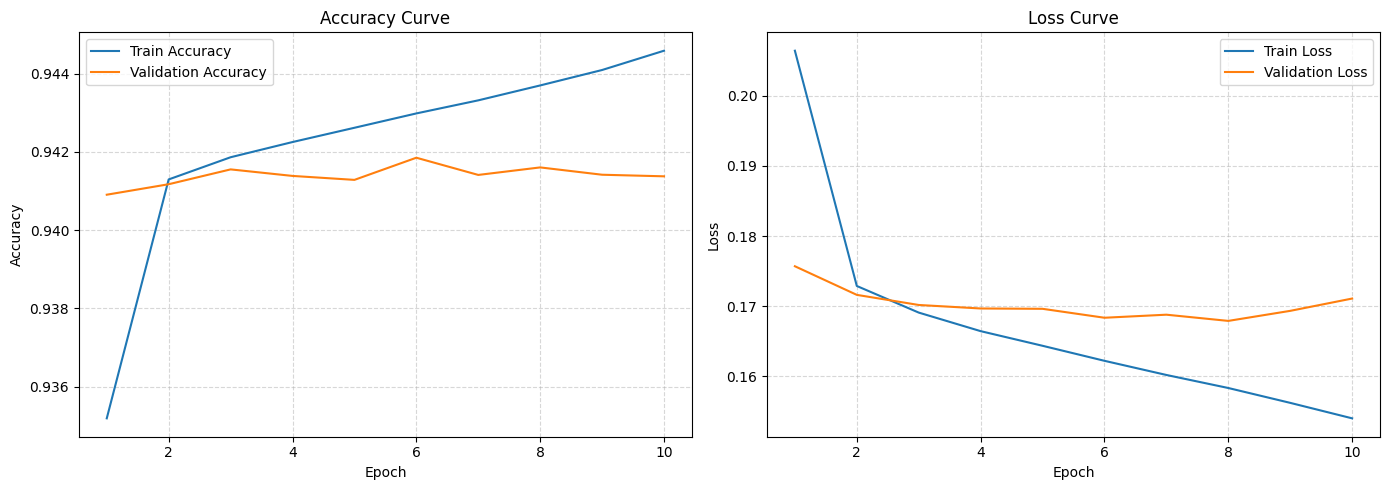

In [ ]:
import matplotlib.pyplot as plt

def plot_logs(logs, save_path="training_curves.png"):
    epochs = range(1, len(logs['train_acc']) + 1)

    plt.figure(figsize=(14, 5))

    # ---- Accuracy Plot ----
    plt.subplot(1, 2, 1)
    plt.plot(epochs, logs['train_acc'], label='Train Accuracy')
    plt.plot(epochs, logs['val_acc'], label='Validation Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    # ---- Loss Plot ----
    plt.subplot(1, 2, 2)
    plt.plot(epochs, logs['train_losses'], label='Train Loss')
    plt.plot(epochs, logs['val_loss'], label='Validation Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    print(f"Saved plot to {save_path}")

    # plt.show()

plot_logs(logs)

## Visualizations
Provide predictions for the X-ray dataset images, and output both the images and their corresponding predicted labels.


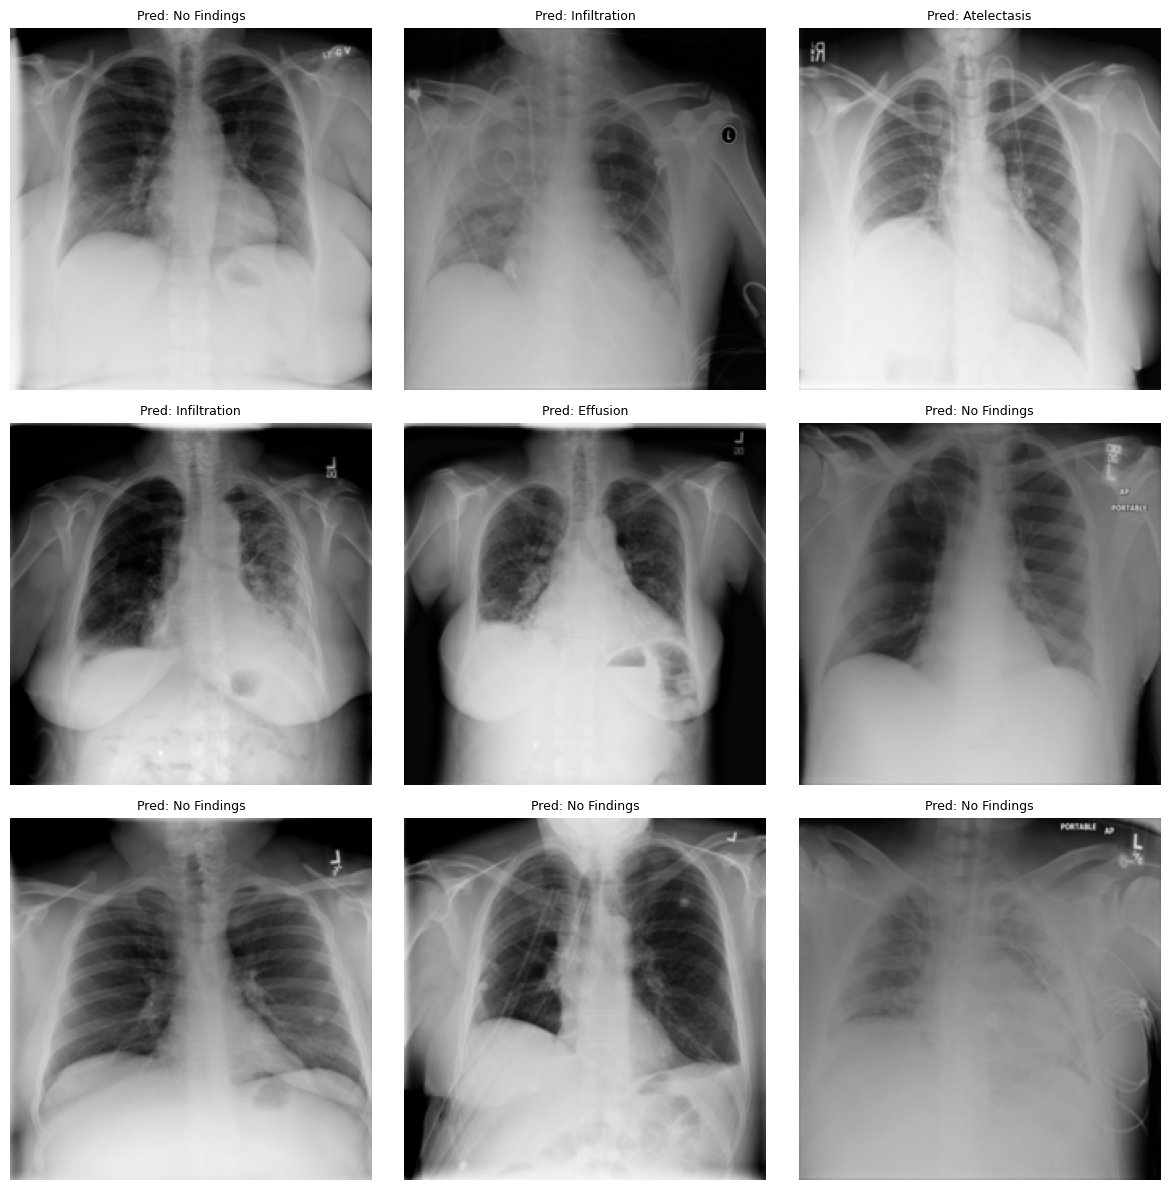

In [ ]:
import torch
import numpy as np

# helper to undo ImageNet normalization for visualization
IMAGENET_MEAN = np.array([0.5, 0.5, 0.5])
IMAGENET_STD  = np.array([0.225, 0.225, 0.225])

def denormalize(img_tensor):
    """
    img_tensor: torch.Tensor, shape [3, H, W], normalized
    returns: numpy array [H, W, 3] in [0,1]
    """
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    img = np.clip(img, 0, 1)
    return img

def show_sample_predictions(model, test_loader, class_names, device, num_images=9, threshold=0.3):
    model.eval()

    # get one batch from test loader
    images, targets = next(iter(test_loader))

    images = images.to(device)

    with torch.no_grad():
        logits = model(images)              # [B, C]
        probs = torch.sigmoid(logits)       # [B, C]

    # move to CPU for processing
    probs = probs.cpu()
    images = images.cpu()

    num_images = min(num_images, images.size(0))

    plt.figure(figsize=(12, 12))

    for i in range(num_images):
        ax = plt.subplot(3, 3, i + 1)

        img = denormalize(images[i])
        plt.imshow(img)
        plt.axis("off")

        # multi-label predictions: all classes above threshold
        p = probs[i]
        pred_indices = (p > threshold).nonzero(as_tuple=True)[0].tolist()

        if len(pred_indices) == 0:
            # if nothing above threshold, fall back to the max one
            pred_indices = [int(torch.argmax(p))]

        pred_labels = [class_names[j] for j in pred_indices]
        pred_str = ", ".join(pred_labels)



        # shorten if too long
        if len(pred_str) > 60:
            pred_str = pred_str[:57] + "..."

        ax.set_title(f"Pred: {pred_str}", fontsize=9)

    plt.tight_layout()
    plt.show()

show_sample_predictions(model, test_loader, CLASS_NAMES, DEVICE, num_images=9, threshold=0.5)


## K-Fold Cross validation function and setups


helper function to define k-fold validation. Some of the functions overlap with previous part.

In [ ]:
# ============================================================
# CONFIG
# ============================================================
DATA_ROOT = "/content/Nih All d"

# ============================================================
# DATA PREP: image_path -> [label_names]
# ============================================================
def build_image_label_map(data_root):
    data_root = Path(data_root)
    image_to_labels = defaultdict(list)

    for cls in CLASS_NAMES:
        folder_candidates = FOLDER_ALIASES.get(cls, [cls])
        folder_path = None
        for cand in folder_candidates:
            p = data_root / cand
            if p.exists():
                folder_path = p
                break

        if folder_path is None:
            print(f"[WARN] Folder for class '{cls}' not found. Tried: {folder_candidates}")
            continue

        for fname in os.listdir(folder_path):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            img_path = str(folder_path / fname)
            image_to_labels[img_path].append(cls)

    print(f"Total unique images found: {len(image_to_labels)}")
    return list(image_to_labels.items())  # [(path, [labels]), ...]

EPOCHS_BASELINE = 10
criterion = nn.BCEWithLogitsLoss()

def train_one_epoch(model, loader, optimizer, epoch, threshold=0.5):
    model.train()
    running_loss = 0.0
    running_ex_acc = 0.0
    total_samples = 0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch}", leave=False)
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_samples += batch_size
        running_loss += loss.item() * batch_size

        # per-example accuracy
        probs = torch.sigmoid(outputs)
        preds = (probs > threshold).float()
        correct = (preds == labels).float()
        ex_acc_batch = correct.mean(dim=1).mean().item()
        running_ex_acc += ex_acc_batch * batch_size

        pbar.set_postfix({
            "loss": f"{running_loss/total_samples:.4f}",
            "ex_acc": f"{100*running_ex_acc/total_samples:.2f}%"
        })

    epoch_loss = running_loss / total_samples
    epoch_ex_acc = running_ex_acc / total_samples
    return epoch_loss, epoch_ex_acc

def eval_one_epoch(model, loader, epoch, prefix="Val", threshold=0.5):
    model.eval()
    running_loss = 0.0
    running_ex_acc = 0.0
    total_samples = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc=f"{prefix} Epoch {epoch}", leave=False)
        for images, labels in pbar:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            total_samples += batch_size
            running_loss += loss.item() * batch_size

            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()
            correct = (preds == labels).float()
            ex_acc_batch = correct.mean(dim=1).mean().item()
            running_ex_acc += ex_acc_batch * batch_size

            pbar.set_postfix({
                "loss": f"{running_loss/total_samples:.4f}",
                "ex_acc": f"{100*running_ex_acc/total_samples:.2f}%"
            })

    epoch_loss = running_loss / total_samples
    epoch_ex_acc = running_ex_acc / total_samples
    return epoch_loss, epoch_ex_acc

# ============================================================
# BASELINE: single train/val split
# ============================================================
def run_baseline_experiment(all_items):
    print("\n===== Baseline: single train/val split =====")

    random.shuffle(all_items)
    n = len(all_items)
    n_train = int(0.8 * n)
    train_items = all_items[:n_train]
    val_items = all_items[n_train:]

    train_ds = NIHMultiLabelDataset(train_items, transform=train_transform)
    val_ds   = NIHMultiLabelDataset(val_items,   transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

    model = build_model(NUM_CLASSES)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    best_val_acc = 0.0
    best_val_loss = float("inf")

    for epoch in range(1, EPOCHS_BASELINE + 1):
        train_loss, train_ex_acc = train_one_epoch(model, train_loader, optimizer, epoch)
        val_loss, val_ex_acc = eval_one_epoch(model, val_loader, epoch, prefix="Val")

        print(f"[Baseline] Epoch {epoch:02d} | "
              f"Train Loss {train_loss:.4f}, Train ExAcc {train_ex_acc*100:.2f}% | "
              f"Val Loss {val_loss:.4f}, Val ExAcc {val_ex_acc*100:.2f}%")

        if val_ex_acc > best_val_acc:
            best_val_acc = val_ex_acc
        if val_loss < best_val_loss:
            best_val_loss = val_loss

    print(f"Baseline best Val ExAcc: {best_val_acc*100:.2f}%, "
          f"best Val Loss: {best_val_loss:.4f}")
    return best_val_acc, best_val_loss

# ============================================================
# K-FOLD CROSS VALIDATION
# ============================================================
def run_kfold_experiment(all_items, n_splits=5):
    print(f"\n===== {n_splits}-Fold Cross Validation =====")

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    all_indices = list(range(len(all_items)))
    fold_results_acc = []
    fold_results_loss = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(all_indices), start=1):
        print(f"\n--- Fold {fold}/{n_splits} ---")

        train_items = [all_items[i] for i in train_idx]
        val_items   = [all_items[i] for i in val_idx]

        train_ds = NIHMultiLabelDataset(train_items, transform=train_transform)
        val_ds   = NIHMultiLabelDataset(val_items,   transform=val_transform)

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, pin_memory=True)

        model = build_model(NUM_CLASSES)
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

        best_val_acc = 0.0
        best_val_loss = float("inf")

        for epoch in range(1, EPOCHS_KFOLD + 1):
            train_loss, train_ex_acc = train_one_epoch(model, train_loader, optimizer, epoch)
            val_loss, val_ex_acc = eval_one_epoch(model, val_loader, epoch, prefix=f"Val F{fold}")

            print(f"[Fold {fold}] Epoch {epoch:02d} | "
                  f"Train Loss {train_loss:.4f}, Train ExAcc {train_ex_acc*100:.2f}% | "
                  f"Val Loss {val_loss:.4f}, Val ExAcc {val_ex_acc*100:.2f}%")

            if val_ex_acc > best_val_acc:
                best_val_acc = val_ex_acc
            if val_loss < best_val_loss:
                best_val_loss = val_loss

        print(f"[Fold {fold}] best Val ExAcc: {best_val_acc*100:.2f}%, "
              f"best Val Loss: {best_val_loss:.4f}")

        fold_results_acc.append(best_val_acc)
        fold_results_loss.append(best_val_loss)

    mean_acc = sum(fold_results_acc) / len(fold_results_acc)
    mean_loss = sum(fold_results_loss) / len(fold_results_loss)

    print(f"\nK-Fold mean best Val ExAcc: {mean_acc*100:.2f}%")
    print(f"K-Fold mean best Val Loss: {mean_loss:.4f}")
    return fold_results_acc, fold_results_loss


all_items = build_image_label_map(DATA_ROOT)

baseline_acc, baseline_loss = run_baseline_experiment(all_items)


Total unique images found: 141310

===== Baseline: single train/val split =====


[Baseline] Epoch 01 | Train Loss 0.2138, Train ExAcc 93.07% | Val Loss 0.1742, Val ExAcc 94.13%


[Baseline] Epoch 02 | Train Loss 0.1733, Train ExAcc 94.11% | Val Loss 0.1706, Val ExAcc 94.18%


[Baseline] Epoch 03 | Train Loss 0.1695, Train ExAcc 94.17% | Val Loss 0.1686, Val ExAcc 94.18%


[Baseline] Epoch 04 | Train Loss 0.1669, Train ExAcc 94.20% | Val Loss 0.1674, Val ExAcc 94.18%


...

[Baseline] Epoch 06 | Train Loss 0.1628, Train ExAcc 94.28% | Val Loss 0.1668, Val ExAcc 94.21%


[Baseline] Epoch 07 | Train Loss 0.1607, Train ExAcc 94.32% | Val Loss 0.1666, Val ExAcc 94.24%


[Baseline] Epoch 08 | Train Loss 0.1588, Train ExAcc 94.36% | Val Loss 0.1668, Val ExAcc 94.23%


[Baseline] Epoch 09 | Train Loss 0.1568, Train ExAcc 94.40% | Val Loss 0.1673, Val ExAcc 94.19%


[Baseline] Epoch 10 | Train Loss 0.1550, Train ExAcc 94.43% | Val Loss 0.1673, Val ExAcc 94.23%
Baseline best Val ExAcc: 94.24%, best Val Loss: 0.1666


In [ ]:
N_SPLITS = 5
EPOCHS_KFOLD = 5
kfold_accs, kfold_losses = run_kfold_experiment(all_items, n_splits=N_SPLITS)

mean_kfold_acc = sum(kfold_accs) / len(kfold_accs)
mean_kfold_loss = sum(kfold_losses) / len(kfold_losses)

print("\n===== SUMMARY: Does K-Fold help? =====")
print(f"Baseline best Val ExAcc: {baseline_acc*100:.2f}% | Loss: {baseline_loss:.4f}")
print(f"{N_SPLITS}-Fold mean best Val ExAcc: {mean_kfold_acc*100:.2f}% | "
        f"Loss: {mean_kfold_loss:.4f}")

if mean_kfold_acc > baseline_acc:
    print("=> On this run, K-Fold Cross Validation gives *higher* average validation accuracy.")
else:
    print("=> On this run, K-Fold Cross Validation does *not* clearly outperform the single split.")




===== 5-Fold Cross Validation =====

--- Fold 1/5 ---


[Fold 1] Epoch 01 | Train Loss 0.2113, Train ExAcc 93.23% | Val Loss 0.1760, Val ExAcc 94.06%


[Fold 1] Epoch 02 | Train Loss 0.1732, Train ExAcc 94.12% | Val Loss 0.1714, Val ExAcc 94.14%


[Fold 1] Epoch 03 | Train Loss 0.1692, Train ExAcc 94.17% | Val Loss 0.1696, Val ExAcc 94.18%


[Fold 1] Epoch 04 | Train Loss 0.1668, Train ExAcc 94.21% | Val Loss 0.1685, Val ExAcc 94.19%


...

[Fold 5] Epoch 01 | Train Loss 0.2098, Train ExAcc 93.30% | Val Loss 0.1751, Val ExAcc 94.11%


[Fold 5] Epoch 02 | Train Loss 0.1730, Train ExAcc 94.11% | Val Loss 0.1715, Val ExAcc 94.12%


[Fold 5] Epoch 03 | Train Loss 0.1690, Train ExAcc 94.18% | Val Loss 0.1687, Val ExAcc 94.19%


[Fold 5] Epoch 04 | Train Loss 0.1665, Train ExAcc 94.22% | Val Loss 0.1685, Val ExAcc 94.22%


[Fold 5] Epoch 05 | Train Loss 0.1642, Train ExAcc 94.25% | Val Loss 0.1675, Val ExAcc 94.22%
[Fold 5] best Val ExAcc: 94.22%, best Val Loss: 0.1675

K-Fold mean best Val ExAcc: 94.21%
K-Fold mean best Val Loss: 0.1678

===== SUMMARY: Does K-Fold help? =====
Baseline best Val ExAcc: 94.24% | Loss: 0.1666
5-Fold mean best Val ExAcc: 94.21% | Loss: 0.1678
=> On this run, K-Fold Cross Validation does *not* clearly outperform the single split.
